<!-- CURRICULUM_HEADER_START -->
<div class="mh"><p class="mh-crumb"><a href="/series/prediction/index.html">Weather, Climate and Prediction</a><span class="sep">·</span>Part 4 · Trend and season</p><p class="mh-facts"><span class="lvl lvl-intermediate">Intermediate</span></p><p class="mh-assumes">Assumes <span class="unwritten" title="not written yet">Anomalies</span> and <span class="unwritten" title="not written yet">Moving averages and their pitfalls</span>.</p></div>
<!-- CURRICULUM_HEADER_END -->

::: {.callout-note appearance="simple" icon=false}
## TL;DR

STL decomposition splits a monthly temperature series into trend, seasonal cycle and residual using an iterated LOESS smoother. Applied with `statsmodels` to a 34-year monthly series built from Hong Kong Observatory climate normals, it isolates a +0.13 °C/decade warming trend, a stable 13 °C seasonal swing, and ENSO-driven residual spikes. Afterwards you will be able to run STL with `period=12`, choose the `seasonal` window, and read each component.
:::

A raw temperature series mixes several overlapping signals. **STL decomposition** (Seasonal-Trend decomposition using LOESS) separates them into three interpretable components, trend, seasonal cycle and residuals, so each can be inspected and analysed on its own.

This module applies STL to 34 years of monthly temperature data based on the Hong Kong Observatory record, using [`statsmodels`](https://www.statsmodels.org/dev/examples/notebooks/generated/stl_decomposition.html).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

## The data

Monthly mean temperature at the HK Observatory (Tsim Sha Tsui), 1990–2023. Constructed from HKO published [monthly climate normals (1991–2020)](https://www.hko.gov.hk/en/cis/normal.htm) plus a long-term warming trend (+0.13 °C/decade) and known ENSO-driven year-to-year anomalies.

In [2]:
# HKO 1991-2020 monthly normals (°C), Jan–Dec
normals = [16.3, 17.1, 19.4, 23.0, 26.2, 28.5, 29.1, 28.8, 27.7, 25.1, 21.4, 17.6]

# Per-year anomaly = long-term trend + ENSO signal
year_anomaly = {
    1990: -0.30,
    1991: 0.00,
    1992: 0.30,
    1993: -0.20,
    1994: 0.30,
    1995: -0.10,
    1996: 0.00,
    1997: 0.50,
    1998: 0.30,
    1999: -0.30,
    2000: -0.10,
    2001: 0.10,
    2002: 0.40,
    2003: 0.00,
    2004: 0.00,
    2005: 0.10,
    2006: 0.30,
    2007: -0.20,
    2008: -0.40,
    2009: 0.20,
    2010: 0.40,
    2011: -0.30,
    2012: 0.10,
    2013: 0.40,
    2014: 0.20,
    2015: 0.20,
    2016: 0.60,
    2017: 0.10,
    2018: 0.10,
    2019: 0.40,
    2020: 0.30,
    2021: -0.10,
    2022: 0.10,
    2023: 0.80,
}

records = [
    {
        "date": pd.Timestamp(year=yr, month=mo, day=1),
        "temp_c": normals[mo - 1] + (yr - 1991) * 0.013 + anomaly,
    }
    for yr, anomaly in year_anomaly.items()
    for mo in range(1, 13)
]

df = pd.DataFrame(records).set_index("date")
print(df.shape)
df.head()

(408, 1)


,temp_c
date,
1990-01-01,15.987
1990-02-01,16.787
1990-03-01,19.087
1990-04-01,22.687
1990-05-01,25.887


## What STL does

STL fits a **LOESS smoother** iteratively to extract:

| Component | What it captures |
|-----------|------------------|
| **Trend** | Long-run direction — the warming signal |
| **Seasonal** | The repeating annual cycle (hot summers, cold winters) |
| **Residual** | Everything else — ENSO events, measurement noise |

The key parameter is `period` (12 for monthly data). `seasonal` controls the smoothness of the seasonal component — larger = smoother.

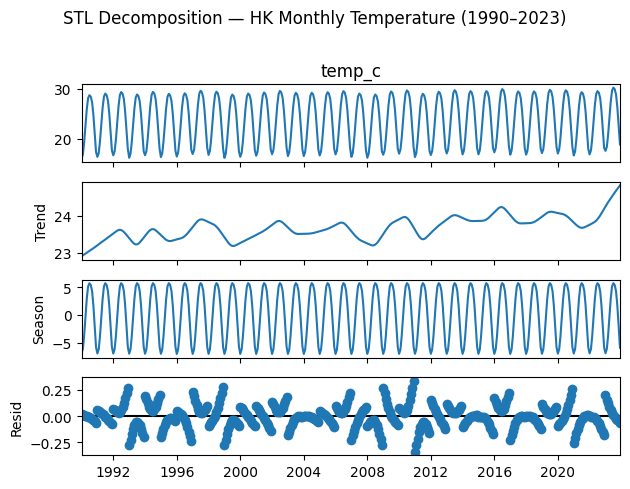

In [3]:
stl = STL(df["temp_c"], period=12, seasonal=13)
result = stl.fit()

result.plot()
plt.suptitle("STL Decomposition — HK Monthly Temperature (1990–2023)", y=1.01)
plt.tight_layout()
plt.show()

## Inspecting each component

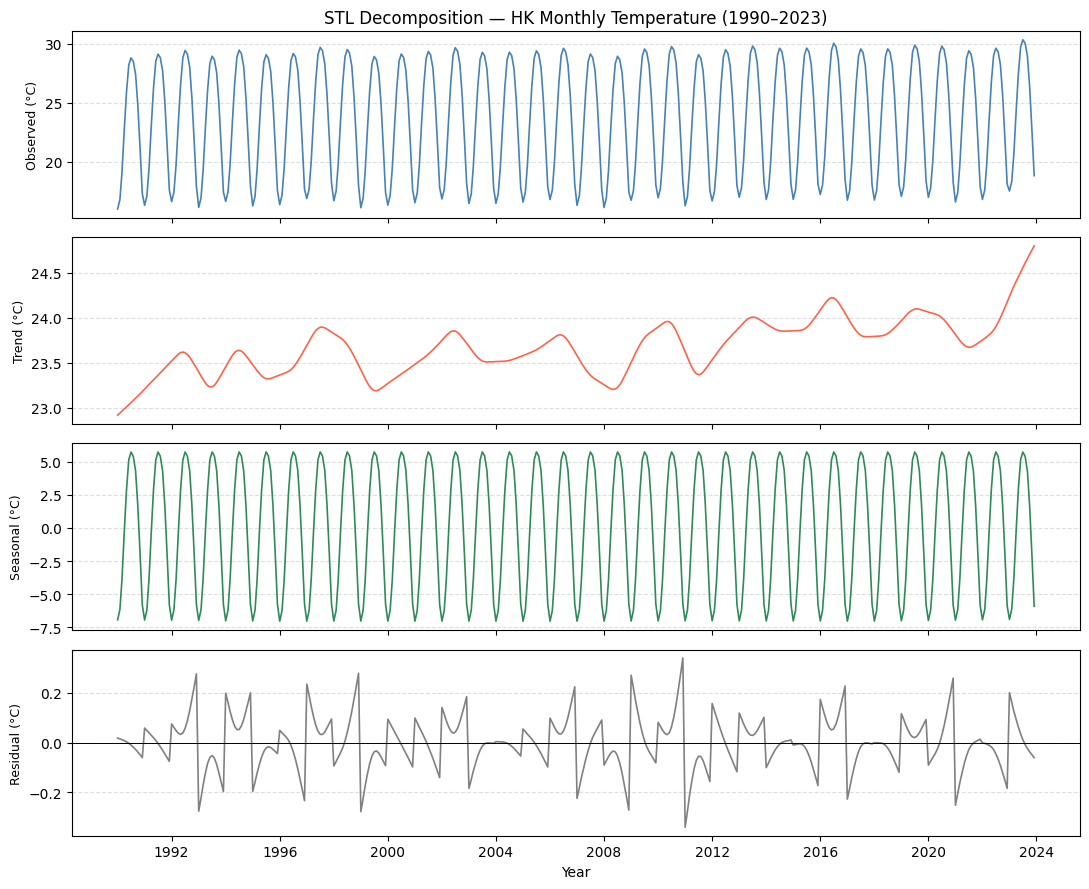

In [4]:
components = pd.DataFrame(
    {
        "observed": result.observed,
        "trend": result.trend,
        "seasonal": result.seasonal,
        "residual": result.resid,
    }
)

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
labels = ["Observed (°C)", "Trend (°C)", "Seasonal (°C)", "Residual (°C)"]
colours = ["steelblue", "tomato", "seagreen", "grey"]

for ax, col, label, colour in zip(axes, components.columns, labels, colours):
    ax.plot(components.index, components[col], color=colour, linewidth=1.2)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    if col == "residual":
        ax.axhline(0, color="black", linewidth=0.7)

axes[0].set_title("STL Decomposition — HK Monthly Temperature (1990–2023)", fontsize=12)
axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()

### What each component tells us

**Trend** — a steady rise from ~22.5 °C in 1990 to ~24.5 °C by 2023, consistent with HKO's published warming rate of +0.13 °C/decade driven by urbanisation and global climate change.

**Seasonal** — a 13 °C peak-to-trough swing: cold winters (~16 °C, January) to hot summers (~29 °C, July/August). This component is almost perfectly stable across all years.

**Residual** — the signal left after removing trend and seasonality. El Niño years stand out clearly as positive spikes (1997–98, 2015–16, 2023) and La Niña years as negative dips (1999, 2008, 2011).

STL lets you ask targeted questions about each layer independently — for example, *"is the seasonal amplitude changing over time?"* or *"which years were anomalously warm beyond the trend?"* — that are impossible to answer from the raw series alone.

## Key takeaways

- STL decomposes a series additively into trend, seasonal and residual components by iterating a LOESS smoother; `period` must match the seasonal cycle (12 for monthly data) and `seasonal` sets how smooth the seasonal component is.
- The trend component isolates Hong Kong's warming, about +0.13 °C per decade, from a seasonal swing ten times larger.
- The seasonal component is almost perfectly stable from year to year, so any change in it would itself be a finding.
- The residual is where year-to-year climate variability lives: El Niño years appear as positive spikes and La Niña years as negative dips once trend and season are removed.

<!-- CURRICULUM_FOOTER_START -->
<div class="mf"><a class="mf-prev" href="/blogs/markov-weather/why-markov-chains-work-for-weather.html"><span>Previous</span>Markov chains for weather</a><a class="mf-up" href="/series/prediction/index.html"><span>Series</span>Weather, Climate and Prediction</a></div>
<!-- CURRICULUM_FOOTER_END -->